# 5 . Medida fisica P: forecasting, VaR/ES y probabilidad de escenarios

Hasta ahora todo se valoro bajo la medida riesgo-neutral Q (`GBM`, deriva `r-q`) -- la que da
PRECIOS de mercado libres de arbitraje, no la que describe hacia donde crees que se movera el
activo de verdad. El modelo `GBM_P` (deriva `mu`, la prima de riesgo esperada real) alimenta
tres medidas Monte Carlo bajo P: `PayoffForecastP` (esperanza fisica de un payoff, tipicamente
el propio activo a vencimiento), `PayoffHitProbabilityP` (probabilidad fisica de que un evento
`trigger` dispare) y `PayoffPnlDistributionP` (VaR/ES de una posicion). El motor RECHAZA
explicitamente pedir una metrica P con un modelo que solo declara Q (o viceversa) -- las dos
medidas no son intercambiables y el motor no deja mezclarlas por error.


In [1]:
import sys
from pathlib import Path

sys.path.insert(0, "../../../build/clients/python")
sys.path.insert(0, "../src")

import math
import numpy as np
import matplotlib.pyplot as plt

import engine
import engine_typed as q
from engine_typed import greeks

print("modulo engine importado desde:", engine.__file__)


modulo engine importado desde: S:\Projects\engine_quant\clients\python\notebooks\../../../build/clients/python\engine.cp312-win_amd64.pyd


## 1. Mercado fisico: prima de riesgo tipica de renta variable (~8-9%)


In [2]:
OBS = "EQ.SPOT.IDX"
S0, MU, SIGMA, R = 100.0, 0.08, 0.22, 0.04

eng = engine.Engine()
model_p = eng.create_model("GBM_P", {"s0": S0, "mu": MU, "sigma": SIGMA, "observable": OBS})
market = engine.MarketSnapshot(pillars=[1.0], zero_rates=[R])
execution = engine.ExecutionContext({"backend": "cpu"})
pricing = engine.PricingContext({"pricing_date": 0.0, "n_paths": 200_000.0, "n_steps": 1.0, "seed": 17.0})

print(f"S0={S0}  mu (fisica)={MU:.1%}  r (riesgo-neutral)={R:.1%}  sigma={SIGMA:.1%}  prima de riesgo={MU - R:.1%}")


S0=100.0  mu (fisica)=8.0%  r (riesgo-neutral)=4.0%  sigma=22.0%  prima de riesgo=4.0%


## 2. Deriva fisica P vs forward riesgo-neutral Q, en horizonte

`PayoffForecastP` sobre el propio activo reproduce `E_P[S_T] = S0*e^{mu*T}`. Un modelo `GBM`
(Q) con el mismo `S0`/`sigma` da el forward `S0*e^{(r-q)*T}` -- ambas curvas divergen con el
horizonte por la prima de riesgo, exactamente lo que separa "cuanto vale hoy" (Q, sin arbitraje)
de "cuanto espero que valga" (P, expectativa fisica real).


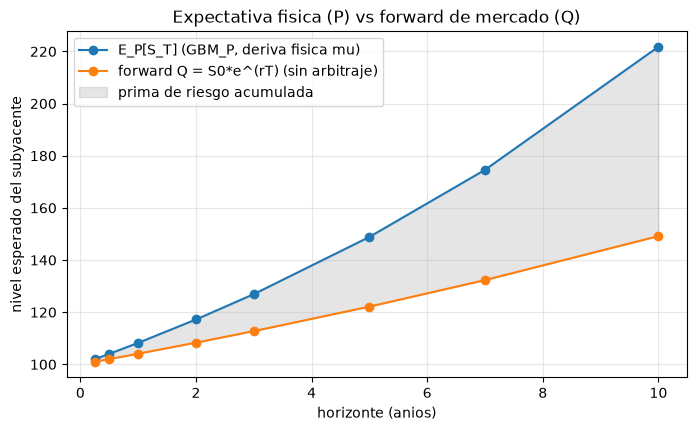

In [3]:
horizons = np.array([0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0])
model_q = eng.create_model("GBM", {"s0": S0, "r": R, "q": 0.0, "sigma": SIGMA, "observable": OBS})

forecast_p, forward_q = [], []
for t in horizons:
    contract = q.when(float(t), q.cashflow("USD", q.fixing(OBS, float(t))))
    product_p = eng.create_product("Payoff", q.PayoffProduct(id=f"FP_{t}", contract=contract).to_params())
    market_t = engine.MarketSnapshot(pillars=[float(t)], zero_rates=[R])
    forecast_p.append(eng.price(product_p, ["PayoffForecastP"], model_p, market_t, pricing, execution)["PayoffForecastP"].scalar)
    forward_q.append(S0 * math.exp(R * t))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(horizons, forecast_p, "o-", label="E_P[S_T] (GBM_P, deriva fisica mu)")
ax.plot(horizons, forward_q, "o-", label="forward Q = S0*e^(rT) (sin arbitraje)")
ax.fill_between(horizons, forward_q, forecast_p, color="grey", alpha=0.2, label="prima de riesgo acumulada")
ax.set_xlabel("horizonte (anios)")
ax.set_ylabel("nivel esperado del subyacente")
ax.set_title("Expectativa fisica (P) vs forward de mercado (Q)")
ax.legend()
ax.grid(alpha=0.3)
plt.show()


## 3. Funcion de supervivencia empirica de S_T bajo P

No hay una medida que devuelva el histograma completo de `S_T` -- pero `PayoffHitProbabilityP`
sobre una barrera `S_T >= K` da exactamente `P(S_T >= K)` para cualquier `K`: barriendo `K` se
reconstruye la funcion de supervivencia empirica (y su derivada discreta aproxima la densidad),
sin acceso directo a las trayectorias simuladas.


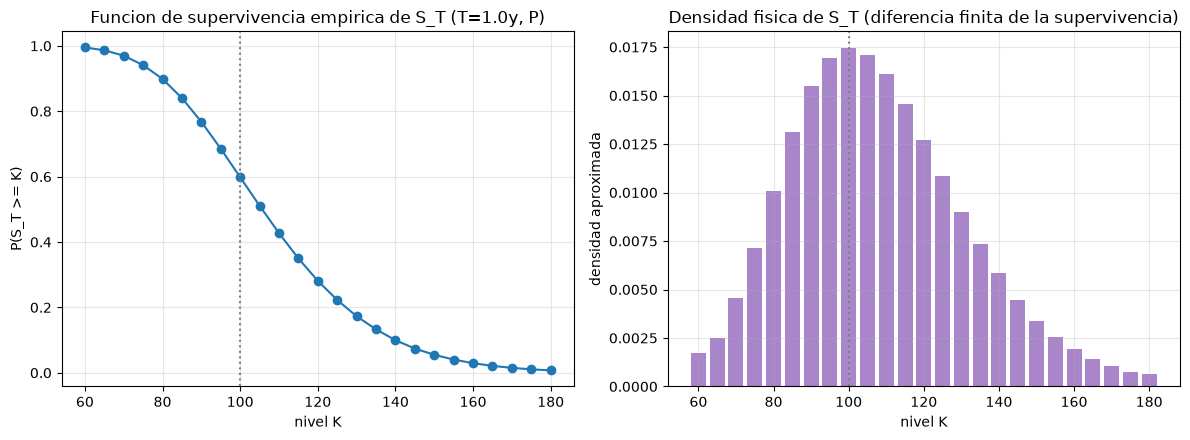

In [4]:
T_HORIZON = 1.0
barrier_levels = np.arange(60.0, 181.0, 5.0)
survival = []
for k in barrier_levels:
    condition = q.greater_equal(q.current(OBS), float(k))
    trigger = q.trigger(
        "HIT", [T_HORIZON], condition, "discrete", "at_hit", 0, True,
        q.when(T_HORIZON, q.cashflow("USD", 1.0)), q.zero(),
    )
    product = eng.create_product("Payoff", q.PayoffProduct(id=f"SURV_{k:.0f}", contract=trigger).to_params())
    result = eng.price(
        product, [("PayoffHitProbabilityP", {"event": "HIT"})], model_p,
        market, pricing, execution,
    )
    survival.append(result["PayoffHitProbabilityP"].scalar)

survival = np.array(survival)
density = -np.gradient(survival, barrier_levels)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(barrier_levels, survival, "o-", color="tab:blue")
axes[0].axvline(S0, color="grey", linestyle=":")
axes[0].set_xlabel("nivel K")
axes[0].set_ylabel("P(S_T >= K)")
axes[0].set_title(f"Funcion de supervivencia empirica de S_T (T={T_HORIZON}y, P)")
axes[0].grid(alpha=0.3)

axes[1].bar(barrier_levels, density, width=4.0, color="tab:purple", alpha=0.8)
axes[1].axvline(S0, color="grey", linestyle=":")
axes[1].set_xlabel("nivel K")
axes[1].set_ylabel("densidad aproximada")
axes[1].set_title("Densidad fisica de S_T (diferencia finita de la supervivencia)")
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()


## 4. VaR y Expected Shortfall de una posicion larga, por nivel de confianza

`PayoffPnlDistributionP` devuelve `.scalar`=PnL esperado, `.primary[0]`=VaR y
`.secondary[0]`=Expected Shortfall al nivel `confidence` pedido -- ES siempre al menos tan
severo como VaR (misma cola, un promedio en vez de un percentil).


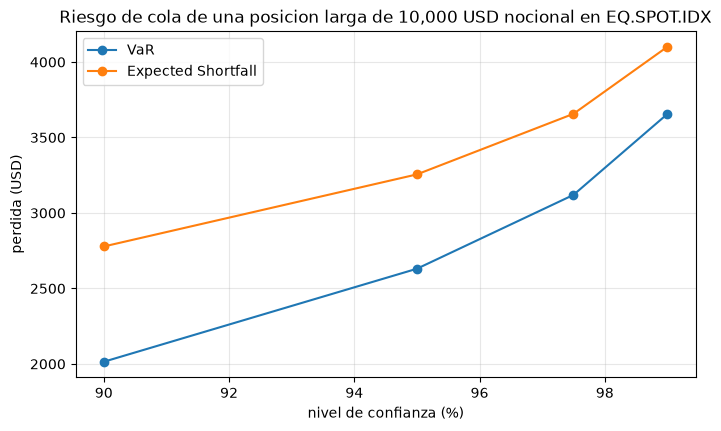

PnL esperado (motor): 824.2   analitico E_P: 832.9
confianza=90.0%  VaR=   2,014.3  ES=   2,778.0
confianza=95.0%  VaR=   2,630.6  ES=   3,255.5
confianza=97.5%  VaR=   3,119.7  ES=   3,656.9
confianza=99.0%  VaR=   3,656.0  ES=   4,101.2


In [6]:
notional = 10_000.0
pnl_contract = q.when(T_HORIZON, q.cashflow("USD", notional * (q.fixing(OBS, T_HORIZON) / S0 - 1.0)))
pnl_product = eng.create_product("Payoff", q.PayoffProduct(id="PNL", contract=pnl_contract).to_params())

confidences = [0.90, 0.95, 0.975, 0.99]
vars_, ess = [], []
for conf in confidences:
    r = eng.price(pnl_product, [("PayoffPnlDistributionP", {"confidence": conf})], model_p, market, pricing, execution)["PayoffPnlDistributionP"]
    vars_.append(r.primary[0])
    ess.append(r.secondary[0])
    if conf == 0.95:
        expected_pnl = r.scalar

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot([c * 100 for c in confidences], vars_, "o-", label="VaR")
ax.plot([c * 100 for c in confidences], ess, "o-", label="Expected Shortfall")
ax.set_xlabel("nivel de confianza (%)")
ax.set_ylabel("perdida (USD)")
ax.set_title(f"Riesgo de cola de una posicion larga de {notional:,.0f} USD nocional en {OBS}")
ax.legend()
ax.grid(alpha=0.3)
plt.show()

analytic_mean = notional * (math.exp(MU * T_HORIZON) - 1.0)
print(f"PnL esperado (motor): {expected_pnl:,.1f}   analitico E_P: {analytic_mean:,.1f}")
for conf, v, e in zip(confidences, vars_, ess):
    print(f"confianza={conf:.1%}  VaR={v:>10,.1f}  ES={e:>10,.1f}")


## 5. Mapa de riesgo de caida: probabilidad de toque vs (nivel de barrera, horizonte)

Un heatmap 2D de `PayoffHitProbabilityP` -- probabilidad fisica de que el activo caiga por
debajo de distintos niveles, en distintos horizontes -- resume el riesgo de cola de un vistazo,
con la fila/columna correspondiente al caso mas cercano al nivel actual de spot resaltada.


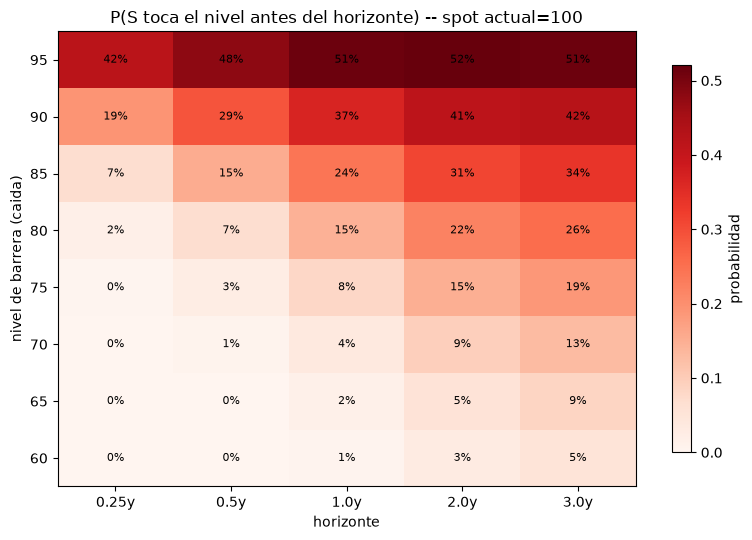

In [7]:
down_levels = np.arange(60.0, 96.0, 5.0)
horizons_grid = np.array([0.25, 0.5, 1.0, 2.0, 3.0])

heat = np.zeros((len(down_levels), len(horizons_grid)))
for i, level in enumerate(down_levels):
    for j, t in enumerate(horizons_grid):
        condition = q.less_equal(q.current(OBS), float(level))
        monitoring_times = list(np.linspace(t / 4.0, t, 4))
        trigger = q.trigger(
            "CRASH", monitoring_times, condition, "discrete", "at_hit", 0, True,
            q.when(float(t), q.cashflow("USD", 1.0)), q.zero(),
        )
        product = eng.create_product("Payoff", q.PayoffProduct(id=f"CRASH_{level:.0f}_{t}", contract=trigger).to_params())
        market_t = engine.MarketSnapshot(pillars=[float(t)], zero_rates=[R])
        result = eng.price(product, [("PayoffHitProbabilityP", {"event": "CRASH"})], model_p, market_t, pricing, execution)
        heat[i, j] = result["PayoffHitProbabilityP"].scalar

fig, ax = plt.subplots(figsize=(8, 5.5))
im = ax.imshow(heat, cmap="Reds", aspect="auto", origin="lower")
ax.set_xticks(range(len(horizons_grid)), [f"{t}y" for t in horizons_grid])
ax.set_yticks(range(len(down_levels)), [f"{l:.0f}" for l in down_levels])
for i in range(len(down_levels)):
    for j in range(len(horizons_grid)):
        ax.text(j, i, f"{heat[i, j]:.0%}", ha="center", va="center", fontsize=8)
ax.set_xlabel("horizonte")
ax.set_ylabel("nivel de barrera (caida)")
ax.set_title(f"P(S toca el nivel antes del horizonte) -- spot actual={S0:.0f}")
fig.colorbar(im, ax=ax, shrink=0.85, label="probabilidad")
plt.tight_layout()
plt.show()


## 6. El motor rechaza mezclar medidas P con modelos Q (y viceversa)

Pedir `PayoffForecastP` sobre un `GBM` (que solo declara Q) falla explicito -- no degrada en
silencio a un numero sin sentido.


In [8]:
try:
    eng.price(pnl_product, ["PayoffForecastP"], model_q, market, pricing, execution)
    print("no debería llegar aqui")
except Exception as e:
    print(f"rechazado como se esperaba: {type(e).__name__}: {e}")


rechazado como se esperaba: ValueError: PayoffForecastPMeasure: modelo no soportado: GBM
